In [252]:
import requests
from IPython.core.display import HTML
# HTML(f"""
# <style>
# @import "https://cdn.jsdelivr.net/npm/bulma@0.9.4/css/bulma.min.css";
# </style>
# """)

### Q5 Exercise Week 7 (Model Complexity, Model seleection and noise)

#### (a) Linear least squares problems for model fitting (design matrix, kernel, lines, polynomials, affine, and other multivariate functions).
- process of model fitting
    - types of linear models (via design matrix / kernel)
        - lines
        - polynomials
        - affine functions
        - multivariate functions (e.g., x and y coordinates) (W05 02)
- Interpretation of results for various types of models 
    - regression metrics ((R)MSE) (W07 02)
    - classification metrics (accuracy, precision, recall, F1-score) (W11 01)

#### (b) Discuss the relationship between data quality, uncertainty, and the challenges of overfitting and underfitting in model learning.
- overfitting/underfitting (W07 02) 
- data quality
    - uncertainty (aleatoric vs. epistemic)
    - noise variance and outliers (W09 02)
    - missing data (W09 03)
    - imbalanced data (W11 01)

#### (c) Discuss how factors affect a model’s ability to generalize to unseen data. Relate this to concepts of data evaluation, such as train-test splits, cross-validation, and performance metrics, to assess a model’s predictive capability and robustness.
- overfitting/underfitting (W07 02) 
- impact of noise variance and outliers (W09 02)
- imbalanced data (W11 01)
- Evaluation methods
    - train-test splits (W07 02)
    - cross-validation ([W07 tutorial 02](../Tutorials/07/02-cv_sklearn.ipynb))
    - performance metrics 
        - regression metrics ((R)MSE, R^2) (W07 02 Task 3-5)
        - classification metrics (accuracy, precision, recall, F1-score) (W11 01)

# Polynomial regression

**Info**
If you're short on time leave this exercise for later and prioritize the next exercises.



In [253]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In this exercise, suppose you want to buy a house in the City of Windsor, Canada. You contact a real-estate salesperson to get information about current house prices and receive details on 546 properties sold in Windsor in the last two years. You would like to figure out what the expected cost of a house might be given only the lot size of the house you want to buy. The dataset has an independent variable, `lotsize`
, specifying the lot size of a property and a dependent variable, `price`
, the sale price of a house. Assume an $N$th-order polynomial relation between `price`
 and `lot-size`
.
The goal is to estimate the best model (in a least-square-sense) that predicts the house price based from lot size.
You will implement a method to estimate the model parameters of  $N$-th order polynomials and use the model to predict the price of a house (in Canadian dollars) based on its lot size (in square feet).
A polynomial _model_ of order $N$ is defined by:

$$
f_\mathbf{w}(x) = \mathbf{w}_0 + \mathbf{w}_1 x + \mathbf{w}_2 x^2 + \dots + \mathbf{w}_N x^N,
$$
in which, the coefficients $\mathbf{w}_i$ are the model parameters and $x$ is the `lot_size`
. 
**Note:** Note that $f_\mathbf{w}$ is linear in the model parameters, $\mathbf{w}$. Solving for the model parameters can be done by setting up the linear set of equations $A \mathbf{w} = y$.

Where

$$
\underbrace{\begin{bmatrix}
    1 & x_1 & x_1^2 & x_1^3 & \dots & x_1^N \\
    1 & x_2 & x_2^2 & x_2^3 & \dots & x_2^N \\
    1 & x_3 & x_3^2 & x_3^3 & \dots & x_3^N \\
    \vdots & \vdots & \vdots & \vdots & \ddots & \vdots \\
    1 & x_m & x_m^2 & x_m^3 & \dots & x_m^N
\end{bmatrix}}_A
\times
\underbrace{\begin{bmatrix}
    \mathbf{w}_0 \\
    \mathbf{w}_1 \\
    \mathbf{w}_2 \\
    \mathbf{w}_3 \\
    \vdots \\
    \mathbf{w}_N
\end{bmatrix}}_\mathbf{w}
=
\underbrace{\begin{bmatrix}
    y_1 \\
    y_2 \\
    y_3 \\
    \vdots \\
    y_m
\end{bmatrix}}_y.
$$
Define the _loss_ $\mathcal{L}$ for a single prediction as the squared error

$$
\mathcal{L}(\hat{y}_i, y_i) = (\hat{y}_i-y_{i})^2,
$$
where $\hat{y}_i=f_{\mathbf{w}}(x_i)$ is the prediction and $y_i$ is the label.
The linear least squares method minimizes the sum of squares. In other words, the parameters $\mathbf{w}$ can be learned by solving the following optimisation problem:

$$
\mathbf{w} = \underset{\mathbf{w}}{\operatorname{argmin}} \frac{1}{m}\sum_{i=1}^{m} \mathcal{L}(\hat{y}_i, y_i) \quad\quad \text{(1)}
$$
**Note:** Recall projecting the vector of labels $\mathbb{y} = \begin{bmatrix} y_1\\y_2\\\vdots\\y_n \end{bmatrix}$ onto the column space of the design matrix defined by $A$ is equivalent to minimizing the mean squared error in Equation 1.

## Data exploration
The following cell loads the dataset and visualizes the data:


Text(0, 0.5, 'House price')

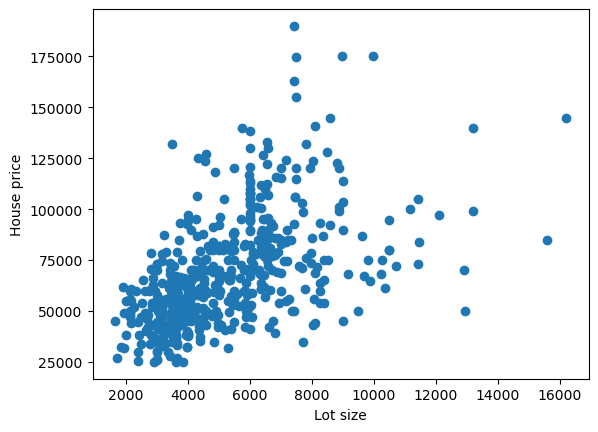

In [254]:
filename = "./data/simple_windsor.csv"
names = ["lotsize", "price"]
dataset = np.loadtxt(filename, delimiter=',').astype(np.int64)

X_full, y_full = dataset.T

plt.scatter(X_full, y_full)
plt.xlabel('Lot size')
plt.ylabel('House price')


---
**Task 1 (easy): Questions💡**
1. In the cell below list and characterize 5 observations about the data.


---

In [255]:
#Observations:
# 1 There seems to be a linear correlation between lot-size and house price trending upwards, i.e. the larger the lot, the more the house costs.
# 2 Most houses seems to be between 2000 and 8000 units in size.
# 3 Price has a high variance
# 4 We do not have a lot of data on really expensive houses.
# 5 The relationship between lot size and price may not be linear for very large or expensive houses (outliers?)


### Splitting into train and test data
The following cell splits the dataset into $80\%$ training data and $20\%$ test data using the scikit-learn library
:


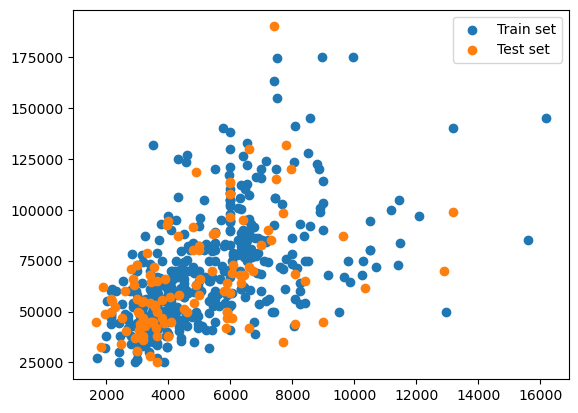

In [256]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
plt.scatter(X_train, y_train, label='Train set')
plt.scatter(X_test, y_test, label='Test set')
plt.legend()
plt.show()

## Polynomial regression
The following exercise guides you through the steps (1-4) for learning the polynomial model.
1. Define the model, e.g. line or polynomial.
2. Identitfy knowns and uknowns.
3. Identify the kernel.
4. Construct the design matrix $A$ for the dataset (see the `get_design_matrix`
 function below).
5. Estimate the model parameters using linear least squares ( [Task 2](#estimate) ).

The function `get_design_matrix`
 (defined in the cell below) creates a design matrix for a polynomial of order $N$.


In [257]:
def get_design_matrix(x, order=1):
    """
    Get the coefficients of polynomial in a least square sense of order N.
    
    :param x: Must be numpy array of size (N).
    :order n: Order of Polynomial.
    """
    
    if order < 1 or x.ndim != 1:
        return x

    count = x.shape[0]
    matrix = np.ones((count, order + 1), np.float64)

    for i in range(1, order+1):
        matrix[:, i] = x**i

    return matrix


---
**Task 2 (medium): Estimate model parameters👩‍💻**
Implement the function `train(X, y, order)`
 in the cell below to learn the model parameters. Use `get_design_matrix(X, order)`
 to create the design matrix.

---

In [258]:
def train(X, y, order):
    """
    :param X: Input vector.
    :param y: Training data values.
    :param order: Order of the model to estimate.
    
    :return: Parameters of model.
    """
    A = get_design_matrix(X, order)
    params = np.linalg.inv(A.T @ A) @ A.T @ y # Formula: w = (X^T X)^(-1) X^T y 
    return params


---
**Task 3 (easy): Define prediction model👩‍💻**
Use the learned model parameters to predict house prices given an input vector $X$ of lot sizes. Implement the prediction function `predict(X, params)`
 in the cell below. 

---

In [259]:
def predict(X, w):
    """
    :param X: Input vector.
    :param w: Estimated parameters.
    
    :return: Predicted y-values.
    """
    A = get_design_matrix(X, order=w.shape[0]-1) # The order is determined by the length of w
    y_pred = A @ w
    return y_pred


---
**Task 4 (easy): Prediction👩‍💻**
In this task you will use the learnt model parameters for making predictions of house prices given lot sizes. Implement the following steps (marked by `#`
) in the code cell below.
1. Learn model parameters using `X_train`
 and `y_train`
. 
2. In the cell below calculate the predicted house prices (`y`
-values) given the lot-sizes defined in the `values`
 variable.
3. Plot the predicted house prices as a line-plot.


---

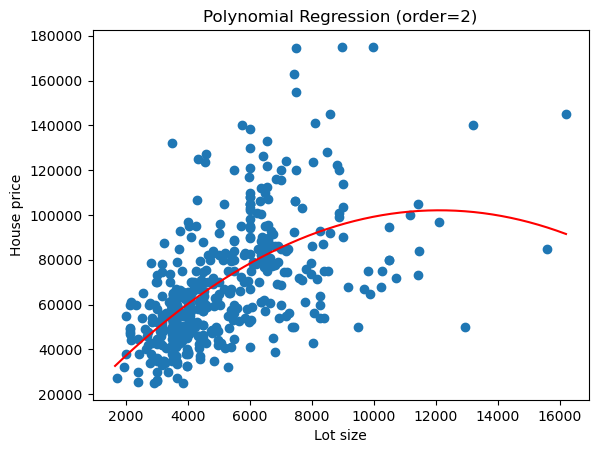

In [278]:
values = np.linspace(X_full.min(), X_full.max(), 50)

# (1) Learn model parameters
order = 2
params = train(X_train, y_train, order)

# (2) Evaluate model
y_pred = predict(values, params)
#y_pred = predict(X_test, params)

# (3) Plot predicted values
plt.scatter(X_train, y_train)
#plt.scatter(X_test, y_test, color='green', label='Test data')
#plt.scatter(X_test, predict(X_test, params), color='orange', label='Predictions on test data')
plt.plot(values, y_pred, color='red')
plt.xlabel('Lot size')
plt.ylabel('House price')
plt.title(f'Polynomial Regression (order={order})')
plt.show()


---
**Task 5 (medium): Order of Polynomial👩‍💻**
In this task you will experiment with the order of the polynomial model to investigate performance.
1. Increase the order of the polynomial, identify the kernel and evaluate the results for:    
    1. A $3$rd-order polynomial.
    2. A $4$th-order polynomial.
    3. A $7$th-order polynomial.
    4. An $11$th-order polynomial.



Observe that the predictions deviate drastically from the actual lot sizes for the $7$th-order polynomial and above. 
1. Explain why this happens? 


---

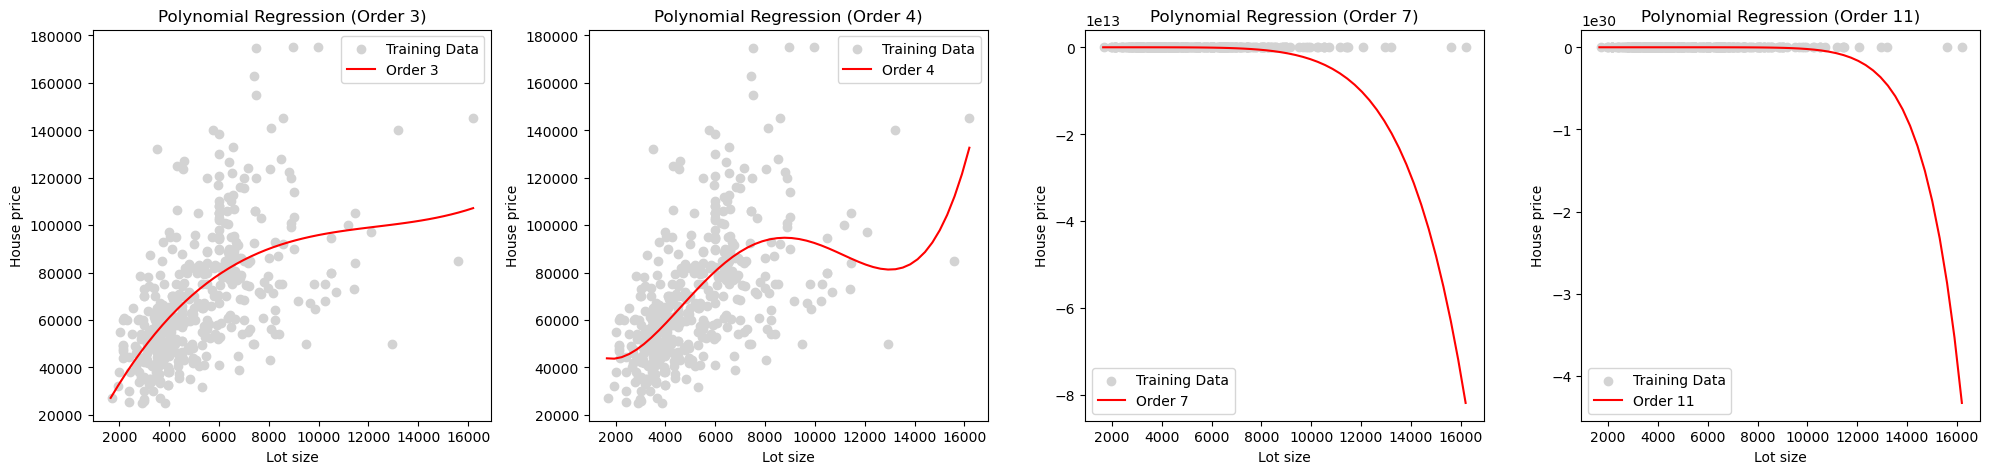

In [261]:
# Write your reflections here...

order = [3, 4, 7, 11]
fig, axs = plt.subplots(1, len(order), figsize=(20, 5))
for i, o in enumerate(order):
    params = train(X_train, y_train, o)
    y_pred = predict(values, params)

    axs[i].scatter(X_train, y_train, color='lightgray', label='Training Data')
    axs[i].plot(values, y_pred, label=f'Order {o}', color='red')
    axs[i].set_title(f'Polynomial Regression (Order {o})')
    axs[i].set_xlabel('Lot size')
    axs[i].set_ylabel('House price')
    axs[i].legend()
plt.tight_layout()
plt.show()

# The predictions deviate drastically from the actual lot sizes for the 7th order polynomial and above.
# This happens due to overfitting. 
# As the polynomial order increases, the model becomes more complex and starts to fit the noise in the training data rather than capturing the underlying trend.
# This results in poor generalization to unseen data, leading to unrealistic predictions for lot sizes that were not part of the training set (e.g., very large lot sizes).

This problem can be solved by normalizing the input vectors. Normalization transforms the input values to the interval $[0, 1]$ by scaling and translating the inputs using the minimum and maximum values.
The cell below provides functions for normalizing and denormalizing (the inverse transformation) input vectors:


In [262]:
def normalized(X):
    n = (X - np.min(X_full))/np.max(X_full)
    return n

def denormalized(X):
    return X*np.max(X_full) + np.min(X_full)


---
**Task 6 (medium):  Higher order polynomials with normalization👩‍💻**
In this task you will redo [Task 4](#learn) using normalization. Write your solution in the cell below.
1. Normalize the inputs in the variable `X_{train}`
 using the function`normalized`
. 
2. Re-train the model parameters using the normalized inputs using $3$rd, $4$th, and $7$th order polynomials as in [Task 4](#learn).
3. Predict the values of (normalized) `X_{test}`
.
4. Plot the predicted result as a curve using `plt.plot`



---

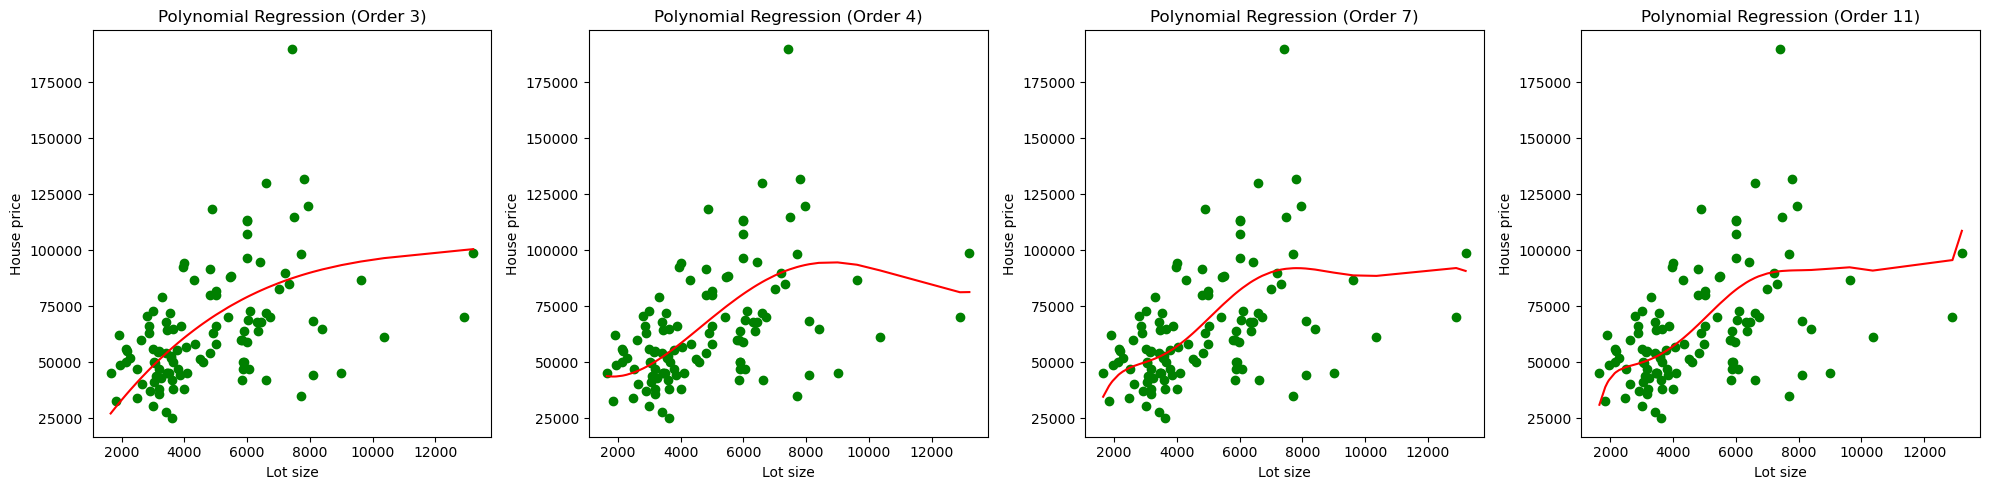

In [263]:
# (1) Normalize the inputs
X_train_n = normalized(X_train)
X_test_n = normalized(X_test)


order = [3,4,7,11]

fig, axs = plt.subplots(1, len(order), figsize=(20, 5))

for i, o in enumerate(order):
    # (2) Learn parameters and predict y-values
    params = train(X_train_n, y_train, o)
    y_predicted = predict(X_test_n, params)

    # Sort X_test and corresponding y_predicted for a smooth plot
    sorted_indices = np.argsort(X_test)
    X_test_sorted = X_test[sorted_indices]
    y_predicted_sorted = y_predicted[sorted_indices]

    # (3) Plot predicted values
    axs[i].scatter(X_test, y_test, c="g")
    axs[i].plot(X_test_sorted, y_predicted_sorted, "r")  # Sorted for a clean plot
    axs[i].set_title(f'Polynomial Regression (Order {o})')
    axs[i].set_xlabel('Lot size')
    axs[i].set_ylabel('House price')
plt.tight_layout()
plt.show()



---
**Task 7 (medium): Normalization improvement💡**
1. Visually inspect and reason about how normalization impacts the results.
2. Explain why normalization achieves a better performance.


---

In [264]:
# Write your answer here

# 1. Visually inspect and reason about how normalization impacts the results.
# Normalization scales the input features to a common range, typically [0, 1].
# This prevents features with larger scales from dominating the learning process (e.g., lot sizes in the thousands vs. prices in the hundreds of thousands).
# A larger order model is extra sensitive to the scale of the input features, since polynomial terms can grow very large very quickly.
# Normalization helps keep these values in a manageable range, improving numerical stability and convergence during training.

# 2. Explain why normalization achieves a better performance.
# Normalization improves the performance of polynomial regression models, especially for higher-order polynomials, by ensuring that all input features contribute equally to the model training.
# E.g. in this model, where house prices generelly where much larger than lot sizes, normalization prevents the model from being biased towards the price feature.
# If we do not normalize, the model might prioritize fitting the larger scale feature (price) at the expense of the smaller scale feature (lot size), leading to suboptimal performance,
# especially for complex models that are more sensitive to feature scales (since polynomial terms can amplify differences in scale).


## Evaluation
In the following steps you will evaluate the models using the _root mean squarred error_ (RMSE) on unseen data (test data). 
The _root mean squared error_ is defined as:

$$
 \sqrt{\frac{1}{m}\sum_{i=1}^{m}(f_{\mathbf{w}}(x_{i})-y_{i})^2}
$$

and calculates the average error measured in the same units as the house prices. 
The code cell below provides an implementation of the RMSE:


In [279]:
def rmse(X, y, w):
    X = normalized(X)
    ym = predict(X, w)
    return np.sqrt(np.mean((y-ym)**2))


---
**Task 8 (easy): Model evaluation👩‍💻**
In this task you will implement the function `evaluate_models`
 to evaluate polynomial models of order 1 to 19 using the _root mean squared error_. 
For each model order:
1. Learn the model parameters using the `train`
 function.
2. Calculate the _root mean squared error_ of the model on the training set.
3. Calculate the _root mean squared error_ of the model on the test set.


---

In [280]:
def evaluate_models():
    """Calculates the RMS error for both training and test data for models with polynomial orders
    from 1 to 19.
    
    Returns: (train losses, test losses)
    """
    losses_train = []
    losses_test = []
    for order in range(1, 19):
        # first, estimate parameters
        params = train(normalized(X_train), y_train, order)
        rmse_train = rmse(X_train, y_train, params)
        rmse_test = rmse(X_test, y_test, params)
        losses_train.append(rmse_train)
        losses_test.append(rmse_test)
    return losses_train, losses_test



---
**Task 9 (easy): Plotting results👩‍💻**
1. Plot the training and test losses in the cell below. 
2. Explain why the test and training losses behave differently as the order of the polynomial increases.
3. Use RMSE and the plot(s) to argue what could be the consequences of using these models given that they have these properties. 


---

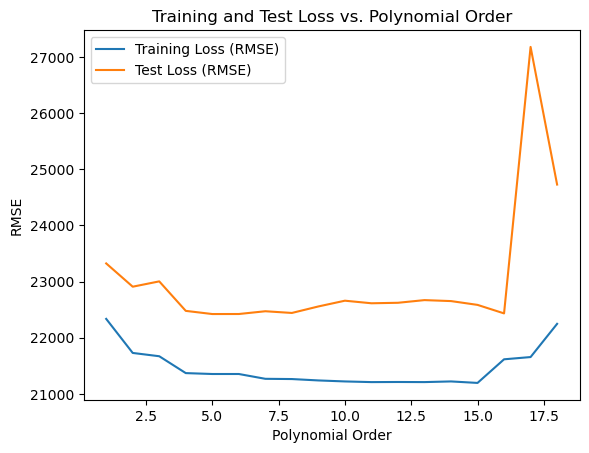

In [281]:
# Write your solution here

# 1. Plot the training and test losses
losses_train, losses_test = evaluate_models()

orders = range(1, 19)
plt.plot(orders, losses_train, label='Training Loss (RMSE)')
plt.plot(orders, losses_test, label='Test Loss (RMSE)')
plt.xlabel('Polynomial Order')
plt.ylabel('RMSE')
plt.title('Training and Test Loss vs. Polynomial Order')
plt.legend()
plt.show()

# 2. Explain why the test and training losses behave differently as the order of the polynomial increases.
# As the polynomial order increases, the training loss (RMSE) typically decreases because the model becomes more complex and can fit the training data more closely.
# However, the test loss (RMSE) may initially decrease but then starts to increase after a certain point, indicating overfitting.
# The model captures noise and fluctuations in the training data that do not generalize well to unseen data.
# Since the model is fitted to the training data, the training loss continues to decrease, 
# but for the unseen test data, the model's performance degrades, leading to higher test loss.

# 3. Use RMSE and the plot(s) to argue what could be the consequences of using these models given that they have these properties. 
# Using models with high polynomial orders can lead to overfitting, where the model performs well on training data but poorly on unseen test data.
# This can result in unreliable predictions and poor generalization to new data, which is undesirable in real-world applications.
# At the other hand, using models with too low polynomial orders can lead to underfitting, where the model is too simple to capture the underlying patterns in the data.
# It is crucial to find a balance between model complexity and generalization ability to ensure robust performance on unseen data.


---
**Task 10 (medium): Reflection💡**
1. Reflect on whether it's possible and reasonable to chose a higher order polynomial for improving the training loss. Use the plot in your argumentation. 


---

In [ ]:
# Write your answers here

# It depends on the specific case. You need to make sure not to underfit or overfit the data.
# Underfitting occurs when the model is too simple to capture the underlying patterns in the data, leading to high bias and poor performance on both training and test data.
# Overfitting occurs when the model is too complex and captures noise in the training data, leading to low training loss but high test loss.
# Both underfitting and overfitting can lead to poor generalization to unseen data, which is undesirable in real-world applications.
# Therefore, it is crucial to find a balance between model complexity and generalization ability.